# ✈️ Predictive Maintenance — NASA C-MAPSS FD001
**Dataset:** Turbofan Engine Degradation Simulation

**Tujuan:** Prediksi Remaining Useful Life (RUL) mesin jet sebelum failure

**Pipeline:**
1. Load & Explore Data (EDA)
2. Feature Engineering (buat label RUL)
3. Preprocessing

4. Train Model (XGBoost)
5. Evaluasi vs Ground Truth RUL

## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print('✅ Libraries loaded!')

C:\Users\asus\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


✅ Libraries loaded!


## 1. Load Data

In [2]:
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

train = pd.read_csv('train_FD001.csv')
test  = pd.read_csv('test_FD001.csv')
rul   = pd.read_csv('RUL_FD001.csv')

print(f'Train : {train.shape}  → {train["unit"].nunique()} mesin')
print(f'Test  : {test.shape}  → {test["unit"].nunique()} mesin')
print(f'RUL   : {rul.shape}   → ground truth untuk tiap mesin di test')
train.head()

Train : (20631, 26)  → 100 mesin
Test  : (13096, 26)  → 100 mesin
RUL   : (100, 1)   → ground truth untuk tiap mesin di test


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. EDA — Eksplorasi Data

=== Distribusi jumlah cycle per mesin (train) ===
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


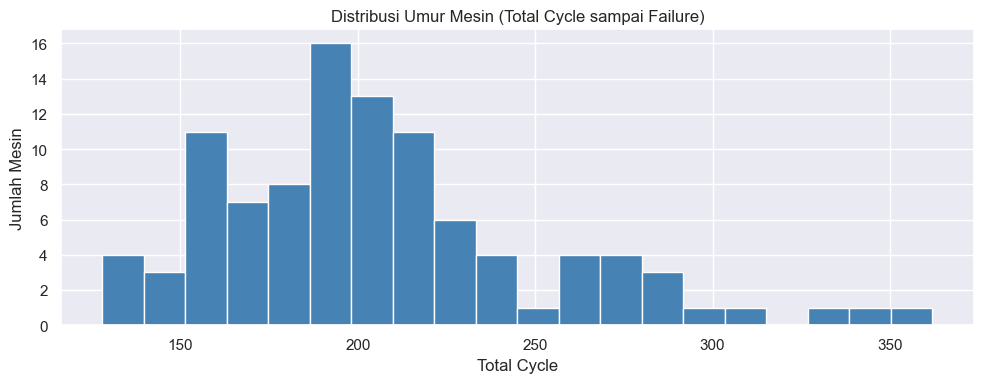

In [3]:
# Cek basic stats
print('=== Distribusi jumlah cycle per mesin (train) ===')
cycle_counts = train.groupby('unit')['cycle'].max()
print(cycle_counts.describe())

plt.figure(figsize=(10, 4))
cycle_counts.hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Distribusi Umur Mesin (Total Cycle sampai Failure)')
plt.xlabel('Total Cycle')
plt.ylabel('Jumlah Mesin')
plt.tight_layout()
plt.show()

Sensor informatif: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


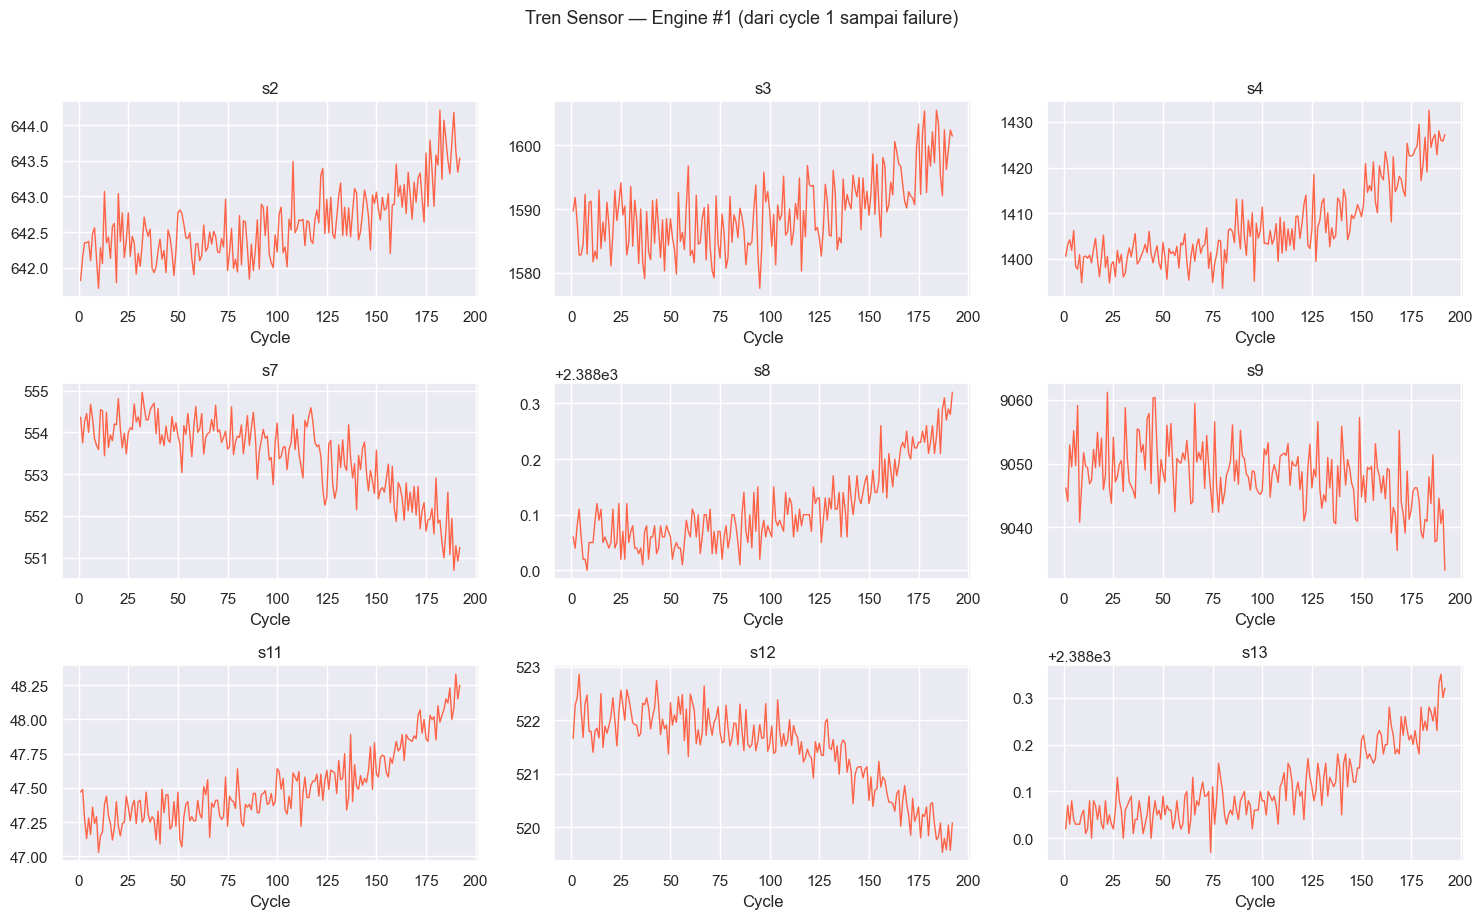

In [4]:
# Sensor yang informatif (tidak konstan)
# s1, s5, s6, s10, s16, s18, s19 biasanya konstan → dibuang
drop_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
useful_sensors = [f's{i}' for i in range(1, 22) if f's{i}' not in drop_sensors]
print(f'Sensor informatif: {useful_sensors}')

# Plot tren beberapa sensor untuk 1 mesin
engine_sample = train[train['unit'] == 1]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.flatten()

for i, sensor in enumerate(useful_sensors[:9]):
    axes[i].plot(engine_sample['cycle'], engine_sample[sensor], color='tomato', linewidth=1)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')

plt.suptitle('Tren Sensor — Engine #1 (dari cycle 1 sampai failure)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

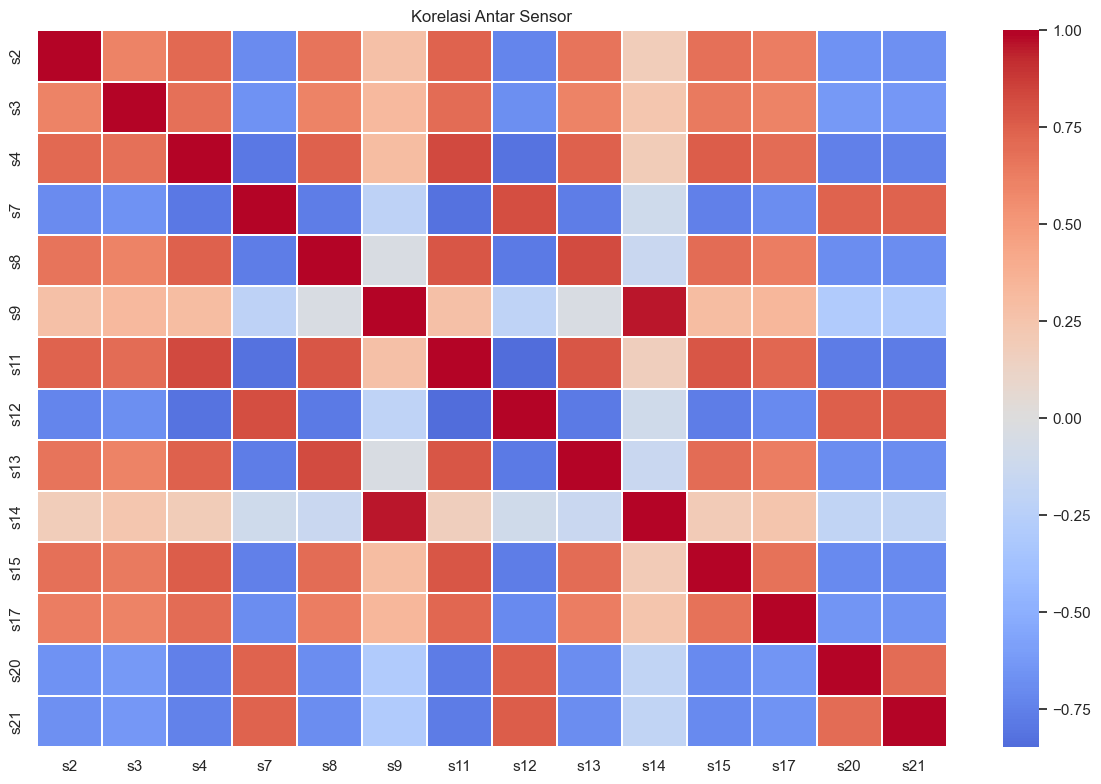

In [5]:
# Korelasi antar sensor
plt.figure(figsize=(12, 8))
corr = train[useful_sensors].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Korelasi Antar Sensor')
plt.tight_layout()
plt.show()

## 3. Feature Engineering — Buat Label RUL

Di data **train**, setiap engine direkam sampai **failure**.
Jadi RUL bisa dihitung:

```
RUL = max_cycle_per_engine - current_cycle
```

Di data **test**, engine di-cut sebelum failure → kita harus **prediksi** sisanya.

In [6]:
# Hitung RUL untuk train
max_cycle = train.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']

train = train.merge(max_cycle, on='unit')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop(columns=['max_cycle'], inplace=True)

print('Contoh RUL di train:')
print(train[['unit', 'cycle', 'RUL']].head(10))

Contoh RUL di train:
   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182


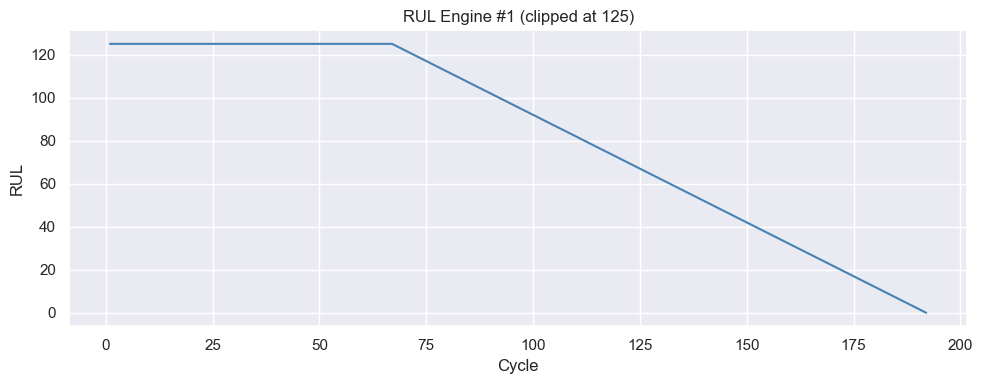

In [7]:
# Banyak riset pakai RUL cap / clip — mesin baru dianggap "sehat" sama semua
# Ini bantu model fokus ke fase degradasi
RUL_CAP = 125
train['RUL_clipped'] = train['RUL'].clip(upper=RUL_CAP)

plt.figure(figsize=(10, 4))
plt.plot(train[train['unit']==1]['cycle'].values,
         train[train['unit']==1]['RUL_clipped'].values, color='steelblue')
plt.title(f'RUL Engine #1 (clipped at {RUL_CAP})')
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [8]:
# Fitur yang dipake: sensor informatif + operational settings
features = ['op1', 'op2', 'op3'] + useful_sensors
target = 'RUL_clipped'

# Drop sensor konstan dari train & test
X_train = train[features]
y_train = train[target]

X_test_raw = test[features]

# Normalisasi MinMax
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test_raw)

print(f'X_train: {X_train_scaled.shape}')
print(f'X_test : {X_test_scaled.shape}')

X_train: (20631, 17)
X_test : (13096, 17)


## 5. Train Model — XGBoost

In [9]:
model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

model.fit(X_train_scaled, y_train)
print('✅ Model trained!')

✅ Model trained!


## 6. Prediksi & Evaluasi

In [10]:
# Prediksi di test: ambil cycle terakhir tiap engine
last_cycle_test = test.groupby('unit').last().reset_index()
X_last = scaler.transform(last_cycle_test[features])

y_pred = model.predict(X_last)
y_true = rul['RUL'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print(f'📊 RMSE : {rmse:.2f}')
print(f'📊 MAE  : {mae:.2f}')
print(f'\nArtinya: rata-rata prediksi meleset {mae:.1f} cycle dari nilai sebenarnya')

📊 RMSE : 17.96
📊 MAE  : 13.28

Artinya: rata-rata prediksi meleset 13.3 cycle dari nilai sebenarnya


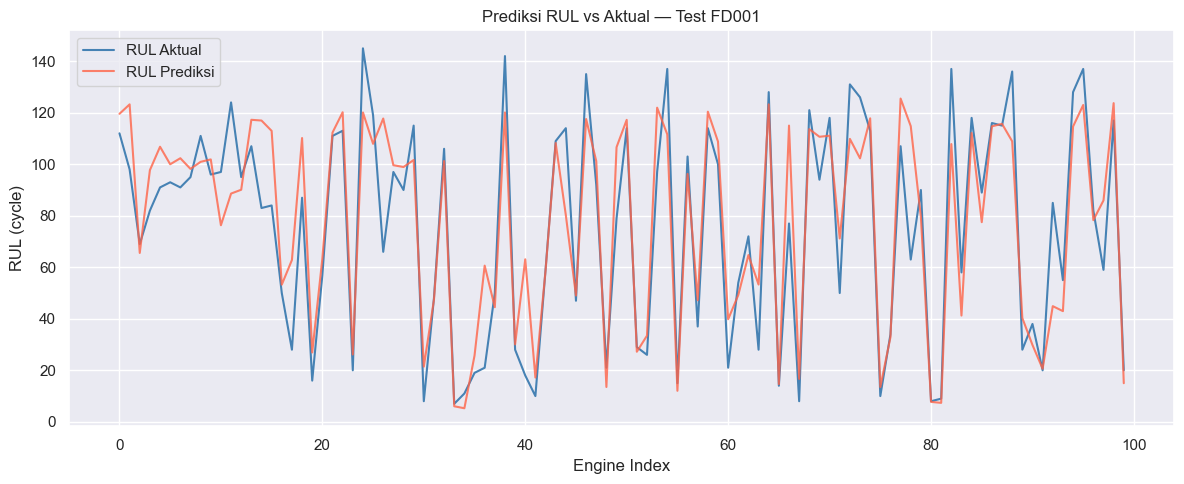

In [11]:
# Visualisasi prediksi vs aktual
plt.figure(figsize=(12, 5))
x_idx = np.arange(len(y_true))
plt.plot(x_idx, y_true, label='RUL Aktual', color='steelblue', linewidth=1.5)
plt.plot(x_idx, y_pred, label='RUL Prediksi', color='tomato', linewidth=1.5, alpha=0.8)
plt.title('Prediksi RUL vs Aktual — Test FD001')
plt.xlabel('Engine Index')
plt.ylabel('RUL (cycle)')
plt.legend()
plt.tight_layout()
plt.show()

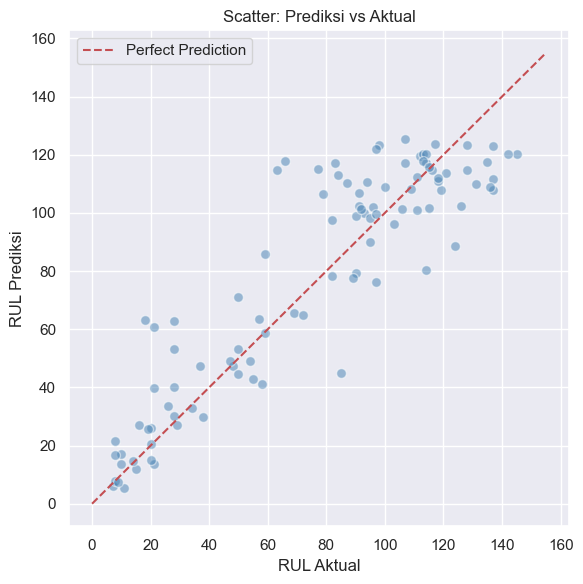

In [12]:
# Scatter plot prediksi vs aktual
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=50)
max_val = max(y_true.max(), y_pred.max()) + 10
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
plt.xlabel('RUL Aktual')
plt.ylabel('RUL Prediksi')
plt.title('Scatter: Prediksi vs Aktual')
plt.legend()
plt.tight_layout()
plt.show()

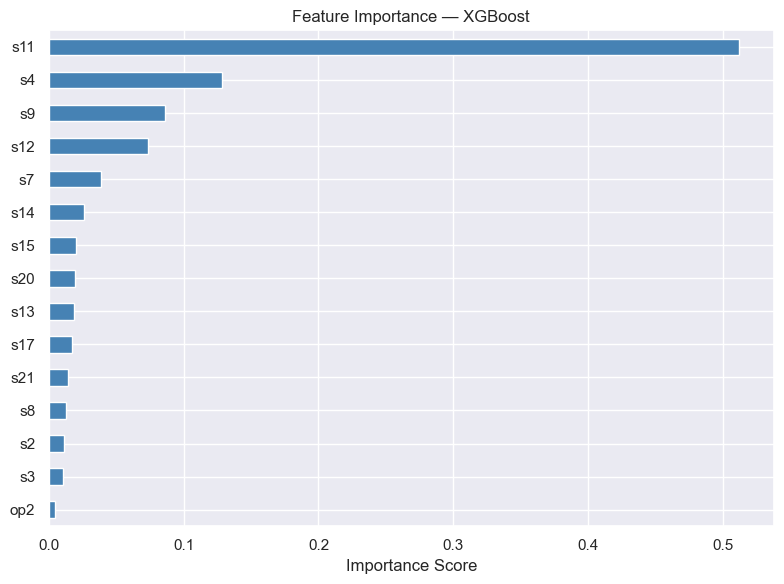

In [13]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()